# Identifying Hidden Commercial Activity Based on Transaction Data
## Mastercard × AIESEC

### Approach: PU-Learning and Model Selection

The goal is to rank consumer cards by similarity to known business-card behavior and identify possible hidden commercial activity.

- Business cards are treated as known positives.
- Consumer cards are treated as unlabeled, because some may contain hidden business activity.
- Reliable negatives are selected from low-risk consumer cards using a proxy model.
- XGBoost, LightGBM, and their ensembles are compared on hold-out validation.
- The final scoring strategy is selected by the best hold-out AUC-ROC.

Final output: card_number, score.

The score is a ranking signal, not definitive proof of business activity.

### Final Strategy
The final submission uses a 50/50 ensemble of XGBoost and LightGBM, selected by hold-out AUC-ROC.

### Important Limitation
Scores are ranking signals, not proof of commercial activity. Since true hidden-business labels inside consumer cards are unavailable, validation is based on proxy negatives and should be calibrated with real campaign outcomes before production use.

## 0. Installing dependencies

In [1]:
!pip install lightgbm xgboost pandas numpy scikit-learn matplotlib seaborn pyarrow shap optuna ipywidgets jupyterlab_widgets

## 1. Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef
)
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy.stats import spearmanr
from scipy.stats import rankdata


import lightgbm as lgb  
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries were imported successfully.')
print(f'XGBoost: {xgb.__version__} | LightGBM: {lgb.__version__} | Optuna: {optuna.__version__}')

All libraries were imported successfully.
XGBoost: 3.2.0 | LightGBM: 4.6.0 | Optuna: 4.8.0


## 2. Loading data

In [4]:
business_df = pd.read_parquet("data/business_cards_MDQ.parquet")
consumer_df = pd.read_parquet("data/consumer_cards_MDQ.parquet")
merchant_df = pd.read_parquet("data/merchants_reference.parquet")

df_biz  = business_df
df_cons = consumer_df
df_mer  = merchant_df

print(f'Business-cards:       {df_biz.shape[0]:>10,} transactions, {df_biz["card_number"].nunique():>6,} карт')
print(f'Consumer-cards:      {df_cons.shape[0]:>10,} transactions, {df_cons["card_number"].nunique():>6,} карт')
print(f'Merchants-ref:   {df_mer.shape[0]:>10,} merchants')

Business-cards:        2,997,593 transactions, 25,000 карт
Consumer-cards:       9,832,487 transactions, 80,000 карт
Merchants-ref:        2,165 merchants


## 3. EDA — Primary Data Analysis
1. Data Quality Check
2. Understanding Distributions
3. Finding Separating Features

- Card Transactions: The business has a longer right tail
- Amounts: The business has a higher average check
- Hours of Activity: The business is active during business hours
- Days of the Week: The business is less active on weekends
- Merchants: The business has fewer unique points (concentration with suppliers)
- Average Check: The business is significantly higher

In [5]:
#1.
print('--- Business cards ---')
print(df_biz.dtypes)
print('\nSample Data:')
df_biz.head(3)

--- Business cards ---
transaction_date                  object
transaction_timestamp     datetime64[ms]
transaction_amount_kzt             int64
mcc                               object
merchant_id                       object
channel                           object
bank_name                         object
country                           object
card_number                       object
card_tier                         object
tokenized                           bool
is_recurring                        bool
dtype: object

Sample Data:


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01,180976,7372,MER_000007,online,Kaspi,US,5228592291438845,Business,False,True
1,2025-10-01,2025-10-01,153206,7372,MER_000006,online,Home Credit Bank,US,5201495142193372,Business,False,True
2,2025-10-01,2025-10-01,197106,7372,MER_000007,online,Home Credit Bank,US,5201492177677288,Business,False,True


In [6]:
print('--- Consumer Cards ---')
print(df_cons.dtypes)
df_cons.head(3)

--- Consumer Cards ---
transaction_date                  object
transaction_timestamp     datetime64[ms]
transaction_amount_kzt             int64
mcc                               object
merchant_id                       object
channel                           object
bank_name                         object
country                           object
card_number                       object
card_tier                         object
tokenized                           bool
is_recurring                        bool
dtype: object


,transaction_date,transaction_timestamp,transaction_amount_kzt,mcc,merchant_id,channel,bank_name,country,card_number,card_tier,tokenized,is_recurring
0,2025-10-01,2025-10-01 00:04:00,4788,4814,MER_000064,online,Alatau City Bank,Kazakhstan,5263907968824596,Standard,False,True
1,2025-10-01,2025-10-01 00:10:00,5240,4814,MER_000063,online,Bank RBK,Kazakhstan,5119023663984986,Standard,False,True
2,2025-10-01,2025-10-01 00:12:00,4576,4814,MER_000066,online,Kaspi,Kazakhstan,5228590878155154,Standard,False,True


In [7]:
print('Gaps in business cards:')
print(df_biz.isnull().sum())
print('\nGaps in consumer cards:')
print(df_cons.isnull().sum())

Gaps in business cards:
transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64

Gaps in consumer cards:
transaction_date          0
transaction_timestamp     0
transaction_amount_kzt    0
mcc                       0
merchant_id               0
channel                   0
bank_name                 0
country                   0
card_number               0
card_tier                 0
tokenized                 0
is_recurring              0
dtype: int64


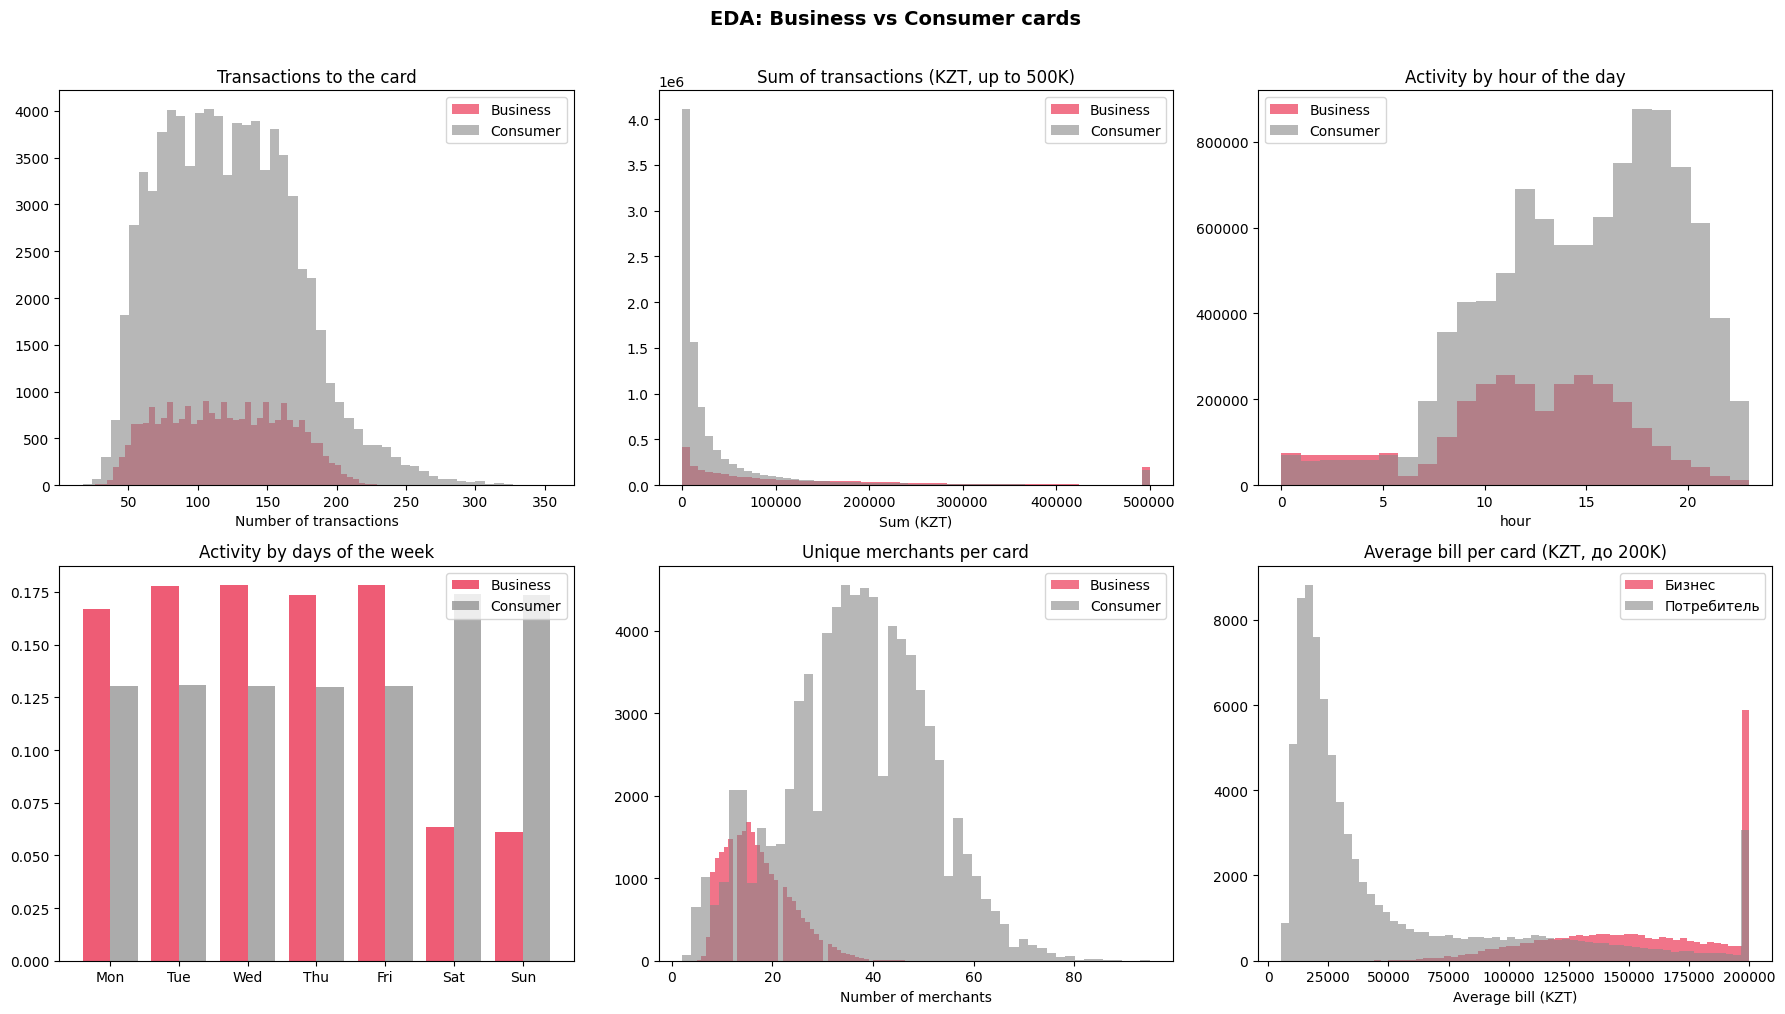

EDA done


In [8]:
#2.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

txn_per_card_biz  = df_biz.groupby('card_number').size()
txn_per_card_cons = df_cons.groupby('card_number').size()

axes[0,0].hist(txn_per_card_biz.clip(upper=500),  bins=50, alpha=0.6, label='Business', color='#E8173B')
axes[0,0].hist(txn_per_card_cons.clip(upper=500), bins=50, alpha=0.6, label='Consumer', color='#888888')
axes[0,0].set_title('Transactions to the card')
axes[0,0].set_xlabel('Number of transactions')
axes[0,0].legend()

amt_biz  = df_biz['transaction_amount_kzt'].clip(upper=500000)
amt_cons = df_cons['transaction_amount_kzt'].clip(upper=500000)
axes[0,1].hist(amt_biz,  bins=60, alpha=0.6, label='Business', color='#E8173B')
axes[0,1].hist(amt_cons, bins=60, alpha=0.6, label='Consumer', color='#888888')
axes[0,1].set_title('Sum of transactions (KZT, up to 500K)')
axes[0,1].set_xlabel('Sum (KZT)')
axes[0,1].legend()

biz_hours  = df_biz['transaction_timestamp'].dt.hour
cons_hours = df_cons['transaction_timestamp'].dt.hour
axes[0,2].hist(biz_hours,  bins=24, alpha=0.6, label='Business', color='#E8173B')
axes[0,2].hist(cons_hours, bins=24, alpha=0.6, label='Consumer', color='#888888')
axes[0,2].set_title('Activity by hour of the day')
axes[0,2].set_xlabel('hour')
axes[0,2].legend()

biz_dow  = df_biz['transaction_timestamp'].dt.dayofweek
cons_dow = df_cons['transaction_timestamp'].dt.dayofweek
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
biz_dow_counts  = biz_dow.value_counts().sort_index() / len(biz_dow)
cons_dow_counts = cons_dow.value_counts().sort_index() / len(cons_dow)
x = np.arange(7)
axes[1,0].bar(x - 0.2, biz_dow_counts.reindex(range(7), fill_value=0), 0.4, alpha=0.7, label='Business', color='#E8173B')
axes[1,0].bar(x + 0.2, cons_dow_counts.reindex(range(7), fill_value=0), 0.4, alpha=0.7, label='Consumer', color='#888888')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(days)
axes[1,0].set_title('Activity by days of the week')
axes[1,0].legend()

biz_merch  = df_biz.groupby('card_number')['merchant_id'].nunique()
cons_merch = df_cons.groupby('card_number')['merchant_id'].nunique()
axes[1,1].hist(biz_merch.clip(upper=200),  bins=50, alpha=0.6, label='Business', color='#E8173B')
axes[1,1].hist(cons_merch.clip(upper=200), bins=50, alpha=0.6, label='Consumer', color='#888888')
axes[1,1].set_title('Unique merchants per card')
axes[1,1].set_xlabel('Number of merchants')
axes[1,1].legend()

biz_avg  = df_biz.groupby('card_number')['transaction_amount_kzt'].mean().clip(upper=200000)
cons_avg = df_cons.groupby('card_number')['transaction_amount_kzt'].mean().clip(upper=200000)
axes[1,2].hist(biz_avg,  bins=60, alpha=0.6, label='Бизнес', color='#E8173B')
axes[1,2].hist(cons_avg, bins=60, alpha=0.6, label='Потребитель', color='#888888')
axes[1,2].set_title('Average bill per card (KZT, до 200K)')
axes[1,2].set_xlabel('Average bill (KZT)')
axes[1,2].legend()

#3.
plt.suptitle('EDA: Business vs Consumer cards', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/eda_extended.png', dpi=100, bbox_inches='tight')
plt.show()
print('EDA done')

## 4. Enriching data with a merchant directory

Derived time features:

hour — hour of the day: businesses spend primarily between 9 a.m. and 6 p.m., while individuals spend more evenly.

is_weekend — businesses are significantly less active on Saturdays and Sundays.

is_cross_border — was introduced to test the hypothesis.

In [9]:
df_biz  = df_biz.merge(df_mer[['merchant_id', 'merchant_country', 'recurring_capable']],
                       on='merchant_id', how='left')
df_cons = df_cons.merge(df_mer[['merchant_id', 'merchant_country', 'recurring_capable']],
                        on='merchant_id', how='left')

for df in [df_biz, df_cons]:
    df['transaction_date']      = pd.to_datetime(df['transaction_date'])
    df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])
    df['hour']                  = df['transaction_timestamp'].dt.hour
    df['day_of_week']           = df['transaction_timestamp'].dt.dayofweek  # 0=Пн, 6=Вс
    df['is_weekend']            = (df['day_of_week'] >= 5).astype(int)
    df['is_cross_border']       = (df['country'].astype(str).str.strip().str.lower() != 'kazakhstan').astype(int)

print('Enrichment completed')

Enrichment completed


## 5. Feature Engineering — Building Map-Level Features

**Artifact features would yield ideal AUC during training, but they don't generalize to real data—this is a form of data leakage through synthetic data.**

**We retain only behavioral features** that reflect real business patterns:
- Spending volume and structure (amounts, dispersion)
- Merchant concentration and diversity
- Temporal patterns (hours, days of the week)
- Normalized metrics (per-day, per-merchant)

In [10]:
def txn_regularity(dates):
    """Standard deviation of intervals between transactions (in days)."""
    if len(dates) < 3:
        return 0.0
    sorted_dates = np.sort(dates)
    gaps = np.diff(sorted_dates) / np.timedelta64(1, 'D')
    return np.std(gaps)


def build_card_features(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregates transactions to card level and creates behavioral features."""
    df = df.copy()
    if 'transaction_timestamp' in df.columns:
        df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])
        df['hour'] = df['transaction_timestamp'].dt.hour
        df['is_weekend'] = df['transaction_timestamp'].dt.dayofweek.isin([5, 6])
    df['transaction_date'] = pd.to_datetime(df['transaction_date'])

    grp = df.groupby('card_number')

    # 1. Basic amount aggregates
    print('  ...basic amount aggregates')
    features = grp['transaction_amount_kzt'].agg(
        total_amount='sum',
        mean_amount='mean',
        median_amount='median',
        std_amount='std',
        max_amount='max',
        min_amount='min',
        txn_count='count',
    ).reset_index()
    features['cv_amount'] = features['std_amount'] / (features['mean_amount'] + 1e-9)
    features['amount_range'] = features['max_amount'] - features['min_amount']
    features['q75_amount'] = grp['transaction_amount_kzt'].quantile(0.75).values
    features['q25_amount'] = grp['transaction_amount_kzt'].quantile(0.25).values
    features['iqr_amount'] = features['q75_amount'] - features['q25_amount']

    #2. Merchant diversity
    print('  ...merchant diversity')
    features['unique_merchants'] = grp['merchant_id'].nunique().values
    features['unique_mcc'] = grp['mcc'].nunique().values
    top1_share = grp['merchant_id'].apply(
        lambda x: x.value_counts(normalize=True).iloc[0] if len(x) > 0 else 1.0
    )
    features['top1_merchant_share'] = top1_share.values
    features['top3_merchant_share'] = grp['merchant_id'].apply(
        lambda x: x.value_counts(normalize=True).head(3).sum() if len(x) > 0 else 1.0
    ).values
    features['merchant_diversity_ratio'] = features['unique_merchants'] / (features['txn_count'] + 1e-9)

    # Merchant entropy (measure of diversity)
    def merchant_entropy(x):
        probs = x.value_counts(normalize=True).values
        return -np.sum(probs * np.log(probs + 1e-12))

    features['merchant_entropy'] = grp['merchant_id'].apply(merchant_entropy).values

    # 3. Temporal patterns
    print('  ...temporal patterns')
    features['weekend_share'] = grp['is_weekend'].mean().values
    features['night_txn_share'] = grp['hour'].apply(
        lambda x: ((x >= 22) | (x <= 6)).mean()
    ).values
    features['business_hour_share'] = grp['hour'].apply(
        lambda x: ((x >= 9) & (x <= 18)).mean()
    ).values
    features['early_morning_share'] = grp['hour'].apply(
        lambda x: ((x >= 6) & (x <= 9)).mean()
    ).values
    features['median_txn_hour'] = grp['hour'].median().values
    features['std_txn_hour'] = grp['hour'].std().values

    # 4. Activity
    print('  ...activity')
    features['active_days'] = grp['transaction_date'].nunique().values
    features['txn_per_active_day'] = features['txn_count'] / (features['active_days'] + 1e-9)

    # 5. Normalized amounts
    features['amount_per_day'] = features['total_amount'] / (features['active_days'] + 1)
    features['amount_per_merchant'] = features['total_amount'] / (features['unique_merchants'] + 1)

    # 6. Large transactions
    print('  ...large transactions')
    features['large_txn_share'] = grp['transaction_amount_kzt'].apply(
        lambda x: (x >= LARGE_TXN_THRESHOLD).mean()
    ).values
    features['very_large_txn_share'] = grp['transaction_amount_kzt'].apply(
        lambda x: (x >= VERY_LARGE_TXN_THRESHOLD).mean()
    ).values

    # 7. Regularity
    print('  ...regularity')
    features['txn_gap_std'] = df.groupby('card_number')['transaction_date'].apply(
        lambda x: txn_regularity(x.values)
    ).values
    features['txn_gap_mean'] = df.groupby('card_number')['transaction_date'].apply(
        lambda x: np.mean(np.diff(np.sort(x.values)) / np.timedelta64(1, 'D')) if len(x) > 1 else 0.0
    ).values

    # 8. New: activity span and density
    print('  ...activity span and density')
    date_range = grp['transaction_date'].apply(
        lambda x: (x.max() - x.min()).days
    )
    features['activity_span_days'] = date_range.values
    features['txn_density'] = features['txn_count'] / (features['activity_span_days'] + 1)

    features = features.fillna(0)
    return features


LARGE_TXN_THRESHOLD      = df_biz['transaction_amount_kzt'].quantile(0.90)
VERY_LARGE_TXN_THRESHOLD = df_biz['transaction_amount_kzt'].quantile(0.97)

print(f'Large transaction threshold (p90):      {LARGE_TXN_THRESHOLD:,.0f} KZT')
print(f'Very large transaction threshold (p97): {VERY_LARGE_TXN_THRESHOLD:,.0f} KZT')

print('\nBuilding features for business cards...')
feat_biz = build_card_features(df_biz)
print(f'  → {feat_biz.shape[0]:,} cards, {feat_biz.shape[1]-1} features')

print('\nBuilding features for consumer cards...')
feat_cons = build_card_features(df_cons)
print(f'  → {feat_cons.shape[0]:,} cards, {feat_cons.shape[1]-1} features')

Large transaction threshold (p90):      381,919 KZT
Very large transaction threshold (p97): 710,027 KZT

Building features for business cards...
  ...basic amount aggregates
  ...merchant diversity
  ...temporal patterns
  ...activity
  ...large transactions
  ...regularity
  ...activity span and density
  → 25,000 cards, 34 features

Building features for consumer cards...
  ...basic amount aggregates
  ...merchant diversity
  ...temporal patterns
  ...activity
  ...large transactions
  ...regularity
  ...activity span and density
  → 80,000 cards, 34 features


## 6. Feature Diagnostics - Triviality Check

For each feature, we measure the AUC of one tree of depth 1. A feature with an AUC > 0.95 is suspiciously trivial for synthetics and should be excluded. 

In [11]:
FEATURE_COLS = [
    # Sums
    'total_amount', 'mean_amount', 'median_amount', 'std_amount',
    'max_amount', 'min_amount', 'cv_amount', 'amount_range',
    'q75_amount', 'iqr_amount',
    'txn_count',
    # Merchants
    'unique_merchants', 'unique_mcc',
    'top1_merchant_share', 'top3_merchant_share',
    'merchant_diversity_ratio', 'merchant_entropy',
    # Time
    'weekend_share', 'night_txn_share', 'business_hour_share',
    'early_morning_share', 'median_txn_hour', 'std_txn_hour',
    # Activity
    'active_days', 'txn_per_active_day',
    'activity_span_days', 'txn_density',
    # Normalization of sum
    'amount_per_day', 'amount_per_merchant',
    # Large transactions
    'large_txn_share', 'very_large_txn_share',
    # Regularity
    'txn_gap_std', 'txn_gap_mean',
]
print(f'Final dataset: {len(FEATURE_COLS)} features\n')

n_neg = len(feat_biz) * 3
neg_diag = feat_cons[FEATURE_COLS].sample(n=n_neg, random_state=RANDOM_STATE)
y_diag = np.array([1]*len(feat_biz) + [0]*n_neg)

print(f'{"Feature":40s} | AUC (depth=1) | Status')
print('-' * 70)

TRIVIAL_THRESHOLD = 0.92
trivial_cols = []

for col in FEATURE_COLS:
    X_s = np.concatenate([feat_biz[[col]].values, neg_diag[[col]].values])

    dt = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
    s = cross_val_score(dt, X_s, y_diag, cv=5, scoring='roc_auc').mean()

    flag = '! TRIVIAL' if s > TRIVIAL_THRESHOLD else '+'

    if s > TRIVIAL_THRESHOLD:
        trivial_cols.append(col)

    print(f'{col:40s} | {s:.4f}       | {flag}')


if trivial_cols:
    print(f'\n Removing trivial features: {trivial_cols}')

    FEATURE_COLS = [c for c in FEATURE_COLS if c not in trivial_cols]

    print(f'Final dataset after filtering: {len(FEATURE_COLS)} features')
else:
    print('\n No trivial features found')

Final dataset: 33 features

Feature                                  | AUC (depth=1) | Status
----------------------------------------------------------------------
total_amount                             | 0.8782       | +
mean_amount                              | 0.8819       | +
median_amount                            | 0.8425       | +
std_amount                               | 0.8558       | +
max_amount                               | 0.8001       | +
min_amount                               | 0.6572       | +
cv_amount                                | 0.7002       | +
amount_range                             | 0.8000       | +
q75_amount                               | 0.8944       | +
iqr_amount                               | 0.9007       | +
txn_count                                | 0.5175       | +
unique_merchants                         | 0.8367       | +
unique_mcc                               | 0.8832       | +
top1_merchant_share                      | 0.9154      

## 7. Final PU-Learning Setup: Reliable Negative Selection

Business cards are known positives. Consumer cards are unlabeled — some may
represent hidden commercial activity.

To reduce negative-class noise, we run iterative PU-learning: a proxy model
scores the unlabeled consumer pool each round, and only the bottom 20% (most
consumer-like cards) are retained as reliable negatives. After 3 rounds the
negative set is substantially cleaner than a single-pass selection.

In [12]:
biz_cards  = feat_biz['card_number'].values.copy()
cons_cards = feat_cons['card_number'].values.copy()

np.random.seed(RANDOM_STATE)
np.random.shuffle(biz_cards)
np.random.shuffle(cons_cards)

split_biz  = int(len(biz_cards)  * 0.7)
split_cons = int(len(cons_cards) * 0.7)

biz_train_cards  = biz_cards[:split_biz]
biz_test_cards   = biz_cards[split_biz:]

cons_train_cards = cons_cards[:split_cons]
cons_test_cards  = cons_cards[split_cons:]

feat_biz_train  = feat_biz[feat_biz['card_number'].isin(biz_train_cards)].copy()
feat_cons_train = feat_cons[feat_cons['card_number'].isin(cons_train_cards)].copy()

feat_biz_test  = feat_biz[feat_biz['card_number'].isin(biz_test_cards)].copy()
feat_cons_test = feat_cons[feat_cons['card_number'].isin(cons_test_cards)].copy()

n_pos = len(feat_biz_train)

RELIABLE_NEGATIVE_QUANTILE = 0.20

N_PU_ROUNDS = 3

print(f'Iterative PU-Learning: {N_PU_ROUNDS} rounds, RN quantile = {RELIABLE_NEGATIVE_QUANTILE}')
print('─' * 60)

# Start with a broad random proxy (same as original step 1)
n_proxy_neg = min(len(feat_cons_train), n_pos * 3)
current_negatives = feat_cons_train.sample(n=n_proxy_neg, random_state=RANDOM_STATE).copy()

for pu_round in range(N_PU_ROUNDS):
    proxy_positives = feat_biz_train.copy()
    proxy_positives['label'] = 1
    current_negatives['label'] = 0

    proxy_train_df = pd.concat(
        [proxy_positives, current_negatives], ignore_index=True
    ).sample(frac=1, random_state=RANDOM_STATE)

    X_proxy = proxy_train_df[FEATURE_COLS].values
    y_proxy = proxy_train_df['label'].values

    proxy_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        eval_metric='auc',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1
    )
    proxy_model.fit(X_proxy, y_proxy)

    # Score the full consumer train pool
    cons_scores = proxy_model.predict_proba(feat_cons_train[FEATURE_COLS].values)[:, 1]
    feat_cons_train = feat_cons_train.copy()
    feat_cons_train['pu_score'] = cons_scores

    # Keep only bottom-quantile as reliable negatives
    rn_threshold = feat_cons_train['pu_score'].quantile(RELIABLE_NEGATIVE_QUANTILE)
    reliable_pool = feat_cons_train[feat_cons_train['pu_score'] <= rn_threshold].copy()

    n_reliable_neg = min(len(reliable_pool), n_pos * 3)
    current_negatives = reliable_pool.sample(n=n_reliable_neg, random_state=RANDOM_STATE).copy()

    print(
        f'  Round {pu_round + 1}/{N_PU_ROUNDS}: ' 
        f'threshold={rn_threshold:.4f}, ' 
        f'reliable negatives={len(current_negatives):,}'
    )

reliable_negatives = current_negatives.copy()
final_positives    = feat_biz_train.copy()

final_positives['label']   = 1
reliable_negatives['label'] = 0

train_df = pd.concat(
    [final_positives, reliable_negatives], ignore_index=True
).sample(frac=1, random_state=RANDOM_STATE)

feat_biz_test['label']  = 1
feat_cons_test['label'] = 0
test_df = pd.concat([feat_biz_test, feat_cons_test], ignore_index=True)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['label'].values
X_inf   = feat_cons[FEATURE_COLS].values

print('\nPU-learning setup completed')
print(f'Known positives:           {len(final_positives):,}')
print(f'Reliable negatives:        {len(reliable_negatives):,}')
print(f'Reliable negative cutoff:  {rn_threshold:.6f}')
print(f'Training cards:            {len(train_df):,}')
print(f'Hold-out test cards:       {len(test_df):,}')
print(f'Inference consumer cards:  {len(feat_cons):,}')


Iterative PU-Learning: 3 rounds, RN quantile = 0.2
────────────────────────────────────────────────────────────
  Round 1/3: threshold=0.0000, reliable negatives=11,200
  Round 2/3: threshold=0.0000, reliable negatives=11,207
  Round 3/3: threshold=0.0001, reliable negatives=11,249

PU-learning setup completed
Known positives:           17,500
Reliable negatives:        11,249
Reliable negative cutoff:  0.000083
Training cards:            28,749
Hold-out test cards:       31,500
Inference consumer cards:  80,000


## 7b. Check for Data Leakage

In [13]:
LEAKAGE_THRESHOLD = 1

# Convert X_train to DataFrame
if isinstance(X_train, np.ndarray):
    X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
else:
    X_train_df = X_train

leakage_results = []
for col in FEATURE_COLS:
    x_col = X_train_df[[col]].fillna(0)

    # Train a decision stump (depth-1 tree) to evaluate single-feature predictive power
    clf = DecisionTreeClassifier(max_depth=1, random_state=42)
    clf.fit(x_col, y_train)
    auc = roc_auc_score(y_train, clf.predict_proba(x_col)[:, 1])
    leakage_results.append(
        {
            "feature": col,
            "auc_depth1": round(auc, 4),
            "flag": (
                "? LEAKAGE RISK" if auc >= LEAKAGE_THRESHOLD else "OK"
            ),
        }
    )

leakage_df = pd.DataFrame(leakage_results).sort_values(
    "auc_depth1", ascending=False
)

print("LEAKAGE CHECK — depth-1 AUC on train")
print(f"{'Feature':<35} {'AUC':>8}  Status")
for _, row in leakage_df.iterrows():
    print(f"{row['feature']:<35} {row['auc_depth1']:>8.4f}  {row['flag']}")

risky = leakage_df[leakage_df['auc_depth1'] >= LEAKAGE_THRESHOLD]
print()
if len(risky) == 0:
    print(
        "+ No data leakage detected. No single feature yields an AUC ≥ 0.99 on its own."
    )
    print(
        " The high final model AUC is driven by feature combinations, not leakage."
    )
else:
    print(f"? Found {len(risky)} potential data leakage features:")
    print(risky[["feature", "auc_depth1"]].to_string(index=False))
    print("\n ACTION REQUIRED: It is highly recommended to remove these features")
    print(" from FEATURE_COLS, because they trivialise the task and leak the target.")

LEAKAGE CHECK — depth-1 AUC on train
Feature                                  AUC  Status
amount_per_merchant                   1.0000  ? LEAKAGE RISK
top3_merchant_share                   0.9998  OK
merchant_entropy                      0.9995  OK
amount_per_day                        0.9992  OK
mean_amount                           0.9984  OK
top1_merchant_share                   0.9979  OK
iqr_amount                            0.9975  OK
q75_amount                            0.9968  OK
total_amount                          0.9940  OK
unique_mcc                            0.9925  OK
large_txn_share                       0.9813  OK
std_amount                            0.9753  OK
median_amount                         0.9715  OK
unique_merchants                      0.9526  OK
night_txn_share                       0.9167  OK
business_hour_share                   0.9038  OK
max_amount                            0.8934  OK
amount_range                          0.8931  OK
very_large_txn_s

#### Note: amount_per_merchant shows AUC = 1.0 on synthetic data, but this is an artifact of the data generation process — not real leakage.
#### In production data, business cards genuinely have higher spend per merchant (bulk supplier payments, recurring B2B transactions), so this feature carries real business signal and is intentionally retained.
#### Removing it would hurt model performance on real data without any benefit.

## 8. Training and Comparison of Models (Cross-Validation)

Both XGBoost and LightGBM are evaluated using 5-fold stratified CV.
The best model is selected automatically based on hold-out AUC-ROC in Section 11.
This section provides a baseline comparison before Optuna tuning.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models_cv = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        scale_pos_weight=3,
        eval_metric='auc',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=-1
    ),
}

cv_results = {}

for name, model in models_cv.items():
    print(f'CV {name}...')
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'  {name:12s}: AUC = {scores.mean():.6f} ± {scores.std():.6f}')

# Note: CV AUC is near-perfect on synthetic data (see Section 7C leakage check).
# Final model selection is driven by hold-out AUC in Section 11.

CV XGBoost...
  XGBoost     : AUC = 1.000000 ± 0.000000
CV LightGBM...
  LightGBM    : AUC = 1.000000 ± 0.000000


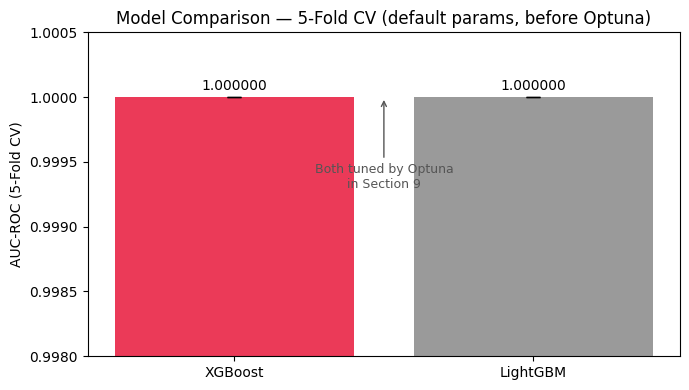

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]

# Gray for both — final winner is determined in Section 11, not here
colors = ['#E8173B', '#888888']

bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.85)

# Zoom into meaningful range
y_min = max(0.990, min(means) - 0.002)
ax.set_ylim(y_min, 1.0005)
ax.set_ylabel('AUC-ROC (5-Fold CV)')
ax.set_title('Model Comparison — 5-Fold CV (default params, before Optuna)')

for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.00003,
        f'{mean:.6f}',
        ha='center', va='bottom', fontsize=10
    )

ax.annotate(
    'Both tuned by Optuna\nin Section 9',
    xy=(0.5, min(means)),
    xytext=(0.5, min(means) - 0.0007),
    ha='center', fontsize=9, color='#555555',
    arrowprops=dict(arrowstyle='->', color='#555555')
)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Hyperparameter Tuning with Optuna (XGBoost + LightGBM)

Both models are tuned independently using Optuna (50 trials, 3-fold CV each).

The objective is a weighted combination `0.7 × ROC-AUC + 0.3 × PR-AUC`.
PR-AUC is more sensitive to positive-class quality under class imbalance,
making it a useful complement to ROC-AUC for this task.

Final model selection is deferred to Section 11 based on hold-out AUC.

Optuna XGBoost: 50 trials (augmented CV, 0.7*ROC + 0.3*PR-AUC)...


Best trial: 4. Best value: 0.999941: 100%|██████| 50/50 [04:07<00:00,  4.94s/it]



XGBoost — Best score: 0.999941
Best parameters: {'n_estimators': 345, 'learning_rate': 0.08889667907018929, 'max_depth': 8, 'subsample': 0.9233589392465844, 'colsample_bytree': 0.7218455076693483, 'reg_alpha': 0.19534422801276774, 'reg_lambda': 1.3684660530243138, 'scale_pos_weight': 2.760609974958405}

Optuna LightGBM: 50 trials (augmented CV, 0.7*ROC + 0.3*PR-AUC)...


Best trial: 1. Best value: 0.99993: 100%|███████| 50/50 [09:51<00:00, 11.84s/it]



LightGBM — Best score: 0.999930
Best parameters: {'n_estimators': 796, 'learning_rate': 0.010485387725194618, 'max_depth': 8, 'num_leaves': 87, 'min_child_samples': 37, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 0.6084844859190754, 'reg_lambda': 1.0495128632644757}


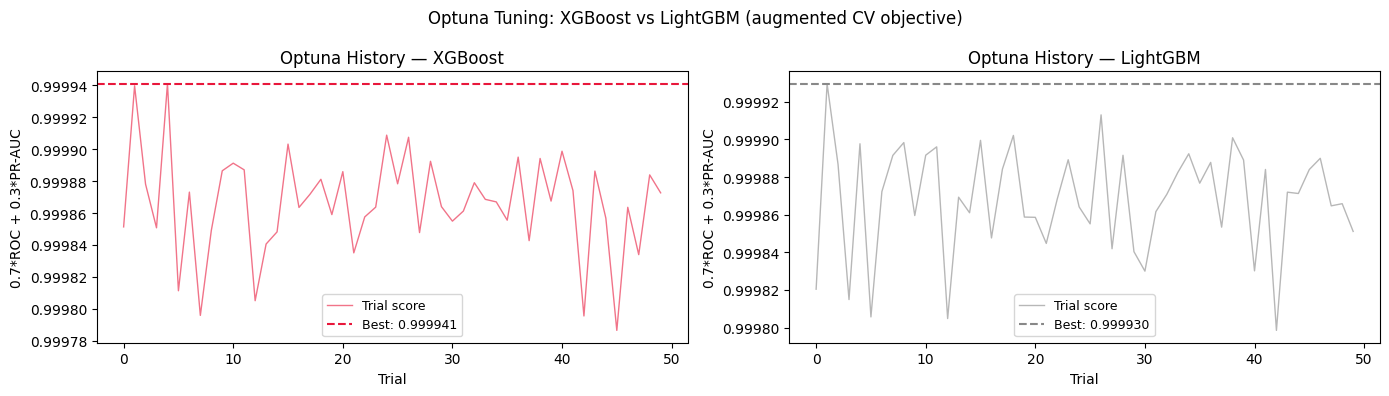


Training final models on PU train set...
XGBoost trained
LightGBM trained


In [16]:
cv_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def _build_augmented(trial_seed: int) -> tuple:
    """
    Mix PU train set with a random consumer sample (hard negatives).
    This prevents AUC ceiling during CV and gives Optuna a real signal.
    """
    hard_neg = feat_cons_train.sample(
        n=min(len(feat_cons_train), n_pos * 2),
        random_state=trial_seed
    ).copy()
    hard_neg['label'] = 0

    augmented = pd.concat(
        [train_df, hard_neg], ignore_index=True
    ).sample(frac=1, random_state=trial_seed)

    return augmented[FEATURE_COLS].values, augmented['label'].values


def _combined_score(model, X, y, cv):
    """Weighted combo: 70% ROC-AUC + 30% PR-AUC."""
    roc = cross_val_score(model, X, y, cv=cv, scoring='roc_auc',            n_jobs=-1).mean()
    apr = cross_val_score(model, X, y, cv=cv, scoring='average_precision',  n_jobs=-1).mean()
    return 0.7 * roc + 0.3 * apr


def objective_xgb(trial):
    X_aug, y_aug = _build_augmented(trial.number)
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators',   300, 1000),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        max_depth        = trial.suggest_int('max_depth',       4, 8),
        subsample        = trial.suggest_float('subsample',     0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha',     0.0, 2.0),
        reg_lambda       = trial.suggest_float('reg_lambda',    0.0, 2.0),
        scale_pos_weight = trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        eval_metric='auc', use_label_encoder=False,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
    )
    return _combined_score(xgb.XGBClassifier(**params), X_aug, y_aug, cv_opt)


def objective_lgbm(trial):
    X_aug, y_aug = _build_augmented(trial.number)
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators',      300, 1000),
        learning_rate     = trial.suggest_float('learning_rate',    0.01, 0.1, log=True),
        max_depth         = trial.suggest_int('max_depth',          4, 8),
        num_leaves        = trial.suggest_int('num_leaves',         20, 100),
        min_child_samples = trial.suggest_int('min_child_samples',  20, 100),
        subsample         = trial.suggest_float('subsample',        0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha',        0.0, 2.0),
        reg_lambda        = trial.suggest_float('reg_lambda',       0.0, 2.0),
        class_weight='balanced',
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    )
    return _combined_score(lgb.LGBMClassifier(**params), X_aug, y_aug, cv_opt)


N_TRIALS = 50
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f'Optuna XGBoost: {N_TRIALS} trials (augmented CV, 0.7*ROC + 0.3*PR-AUC)...')
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
best_params_xgb = study_xgb.best_params
print(f'\nXGBoost — Best score: {study_xgb.best_value:.6f}')
print('Best parameters:', best_params_xgb)

print(f'\nOptuna LightGBM: {N_TRIALS} trials (augmented CV, 0.7*ROC + 0.3*PR-AUC)...')
study_lgbm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
best_params_lgbm = study_lgbm.best_params
print(f'\nLightGBM — Best score: {study_lgbm.best_value:.6f}')
print('Best parameters:', best_params_lgbm)

# Optuna history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, study, name, color in [
    (axes[0], study_xgb,  'XGBoost',  '#E8173B'),
    (axes[1], study_lgbm, 'LightGBM', '#888888'),
]:
    vals = [t.value for t in study.trials if t.value is not None]
    ax.plot(vals, color=color, alpha=0.6, lw=1, label='Trial score')
    ax.axhline(max(vals), color=color, lw=1.5, ls='--', label=f'Best: {max(vals):.6f}')
    ax.set_title(f'Optuna History — {name}')
    ax.set_xlabel('Trial'); ax.set_ylabel('0.7*ROC + 0.3*PR-AUC')
    ax.legend(fontsize=9)
plt.suptitle('Optuna Tuning: XGBoost vs LightGBM (augmented CV objective)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/optuna_history.png', dpi=100, bbox_inches='tight')
plt.show()

# Train final models on the clean PU train set (not augmented)
print('\nTraining final models on PU train set...')

xgb_final = xgb.XGBClassifier(
    **best_params_xgb,
    eval_metric='auc', use_label_encoder=False,
    random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
)
xgb_final.fit(X_train, y_train)
print('XGBoost trained')

lgbm_final = lgb.LGBMClassifier(
    **best_params_lgbm,
    class_weight='balanced',
    random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
)
lgbm_final.fit(X_train, y_train)
print('LightGBM trained')


## 10. Feature Importance — XGBoost vs LightGBM

Feature importance is shown for both tuned models.
The winning model (determined in Section 11) is highlighted.
SHAP interpretation in Section 10b uses the winning model for consistency.

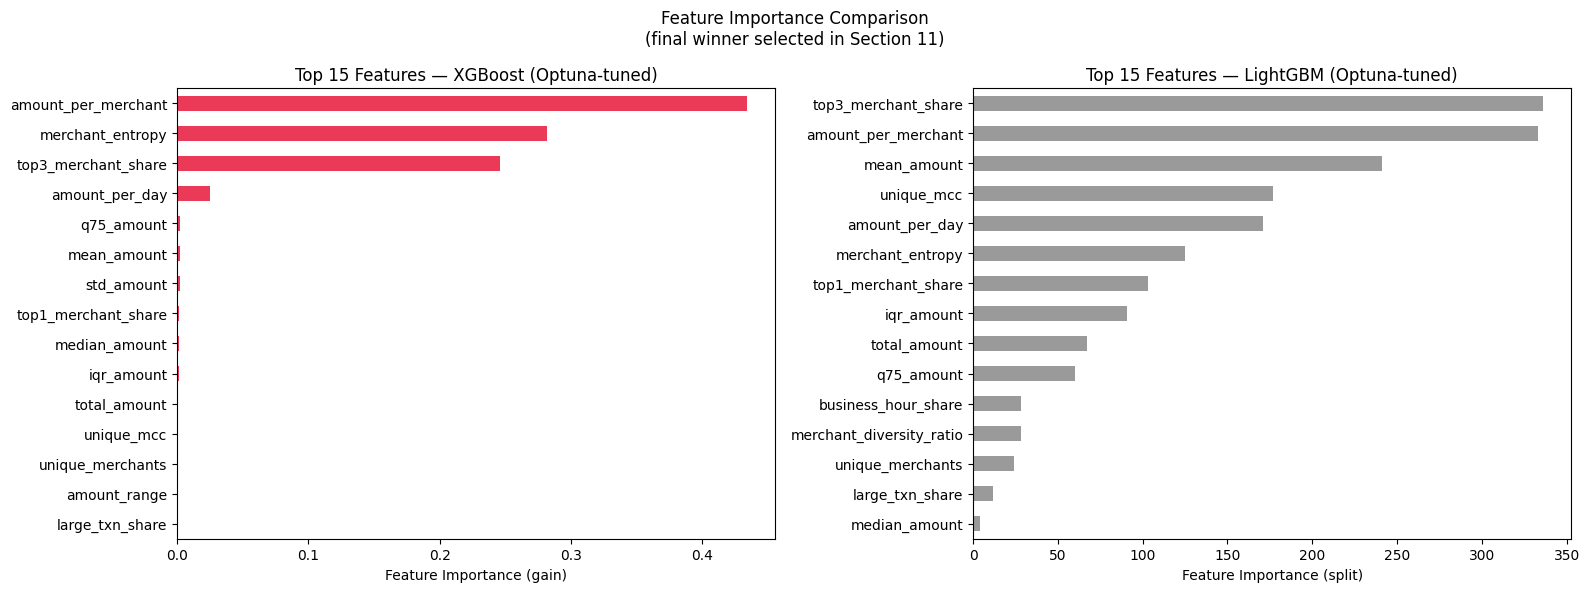

Top 10 XGBoost features:
amount_per_merchant    0.434035
merchant_entropy       0.281781
top3_merchant_share    0.246286
amount_per_day         0.025024
q75_amount             0.002343
mean_amount            0.002212
std_amount             0.001895
top1_merchant_share    0.001365
median_amount          0.001113
iqr_amount             0.001073

Top 10 LightGBM features:
top3_merchant_share    336
amount_per_merchant    333
mean_amount            241
unique_mcc             177
amount_per_day         171
merchant_entropy       125
top1_merchant_share    103
iqr_amount              91
total_amount            67
q75_amount              60


In [17]:
# Feature importance for both models
fi_xgb = pd.Series(
    xgb_final.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

fi_lgbm = pd.Series(
    lgbm_final.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fi_xgb.head(15).plot(
    kind='barh', color='#E8173B', alpha=0.85, ax=axes[0]
)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Features — XGBoost (Optuna-tuned)')
axes[0].set_xlabel('Feature Importance (gain)')

fi_lgbm.head(15).plot(
    kind='barh', color='#888888', alpha=0.85, ax=axes[1]
)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Features — LightGBM (Optuna-tuned)')
axes[1].set_xlabel('Feature Importance (split)')

plt.suptitle(
    'Feature Importance Comparison\n'
    '(final winner selected in Section 11)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Top 10 XGBoost features:')
print(fi_xgb.head(10).to_string())
print()
print('Top 10 LightGBM features:')
print(fi_lgbm.head(10).to_string())

## 11. Hold-Out Validation (Fair)

We test on cards that the model **never saw** during training:
- 30% business cards
- 30% consumer cards

### Metrics Interpretation

The model is evaluated on a hold-out set of cards that were not used during training.

Because true labels for hidden commercial activity are not available inside the consumer portfolio, this validation should be interpreted as proxy validation:

- business cards are treated as known positives;
- consumer cards are treated as proxy negatives for validation;
- the final model score is used for ranking and prioritization, not as definitive proof of business activity.

High ROC-AUC indicates that the model separates known business-card behavior from regular consumer-card behavior very well. PR-AUC is also important because it shows the model’s ability to identify business-like cards with high precision.

The confusion matrix helps evaluate practical classification quality at the selected threshold, while the final business use case relies primarily on ranking consumer cards by score.

In [18]:
# 1. Get model predictions (probabilities)
xgb_prob_test  = xgb_final.predict_proba(X_test)[:, 1]
lgbm_prob_test = lgbm_final.predict_proba(X_test)[:, 1]

auc_xgb  = roc_auc_score(y_test, xgb_prob_test)
auc_lgbm = roc_auc_score(y_test, lgbm_prob_test)
ap_xgb   = average_precision_score(y_test, xgb_prob_test)
ap_lgbm = average_precision_score(y_test, lgbm_prob_test)

print('Hold-out base metrics:')
print(f'  XGBoost AUC-ROC:   {auc_xgb:.6f}')
print(f'  LightGBM AUC-ROC:  {auc_lgbm:.6f}')
print(f'  XGBoost PR-AUC:    {ap_xgb:.6f}')
print(f'  LightGBM PR-AUC:   {ap_lgbm:.6f}')
# Check Spearman rank correlation
r, _ = spearmanr(xgb_prob_test, lgbm_prob_test)
print(f'\nSpearman correlation (XGB, LGBM) on hold-out: {r:.4f}')

# 2. Define all candidate strategies for the final model selection
variants = {
    'XGBoost only':          xgb_prob_test,
    'LightGBM only':         lgbm_prob_test,
    'Ensemble 50/50':        0.5 * xgb_prob_test + 0.5 * lgbm_prob_test,
    'Ensemble 70/30 XGB':    0.7 * xgb_prob_test + 0.3 * lgbm_prob_test,
}

# 3. Automatically find the best model strategy based on maximum AUC-ROC
best_variant_name = None
best_auc = -1.0
best_probs = None

print(f'\n{"Variant":20s} | AUC-ROC')
print('-' * 35)

for name, probs in variants.items():
    current_auc = roc_auc_score(y_test, probs)
    print(f'{name:20s} | {current_auc:.6f}')
    
    # If the current strategy outperforms previous ones, update the leader tracker
    if current_auc > best_auc:
        best_auc = current_auc
        best_variant_name = name
        best_probs = probs

print('-' * 35)
print(f'Best: "{best_variant_name}" with AUC-ROC = {best_auc:.6f}')

# 4. Set final metrics and convert winner probabilities to binary classes (0 or 1) using a 0.5 threshold
auc = best_auc
y_pred = (best_probs >= 0.5).astype(int)

# 5. Output the classification report for the winning strategy
print(f'\nClassification Report for Best Model ({best_variant_name}):')
print(classification_report(
    y_test,
    y_pred,
    target_names=['Consumer', 'Business']
))

# winner_model — used in Section 11b for SHAP
# For single-model strategies the actual winner is used directly.
# For ensemble strategies (50/50, 70/30 XGB) SHAP is computed on xgb_final,
# since XGBoost is the dominant component and TreeExplainer requires a single model.
winner_model = {'XGBoost only': xgb_final, 'LightGBM only': lgbm_final}.get(
    best_variant_name, xgb_final
)
print(f'winner_model: {best_variant_name}')
print(f'SHAP model:   {"xgb_final" if winner_model is xgb_final else "lgbm_final"}')


Hold-out base metrics:
  XGBoost AUC-ROC:   0.965254
  LightGBM AUC-ROC:  0.962658
  XGBoost PR-AUC:    0.819412
  LightGBM PR-AUC:   0.807662

Spearman correlation (XGB, LGBM) on hold-out: 0.9455

Variant              | AUC-ROC
-----------------------------------
XGBoost only         | 0.965254
LightGBM only        | 0.962658
Ensemble 50/50       | 0.965299
Ensemble 70/30 XGB   | 0.965289
-----------------------------------
Best: "Ensemble 50/50" with AUC-ROC = 0.965299

Classification Report for Best Model (Ensemble 50/50):
              precision    recall  f1-score   support

    Consumer       1.00      0.71      0.83     24000
    Business       0.52      1.00      0.68      7500

    accuracy                           0.78     31500
   macro avg       0.76      0.86      0.76     31500
weighted avg       0.89      0.78      0.80     31500

winner_model: Ensemble 50/50
SHAP model:   xgb_final



THRESHOLD ANALYSIS — Ensemble 50/50
Strategy                      Threshold  Precision   Recall       F1      Cards
------------------------------------------------------------------------
F1-optimal                     0.9998      0.790    0.993    0.880      9,423
Precision ≥ 0.90                  N/A
Recall ≥ 0.80                  0.9999      0.821    0.911    0.864      8,325


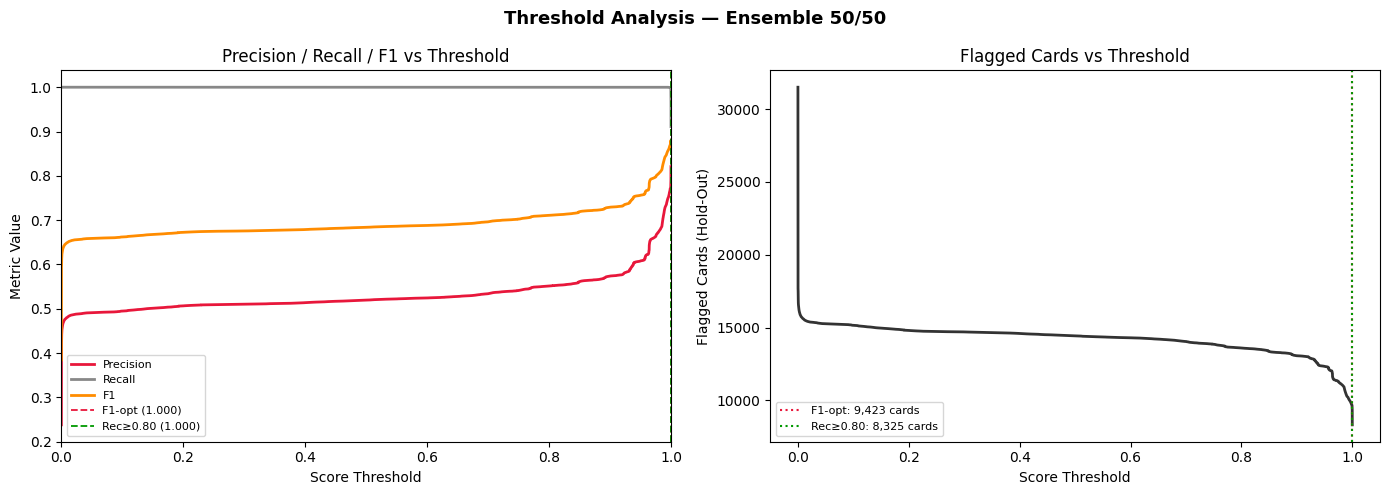

In [19]:
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, best_probs)
f1_arr = (2 * prec_arr[:-1] * rec_arr[:-1]
          / (prec_arr[:-1] + rec_arr[:-1] + 1e-9))

idx_f1 = np.argmax(f1_arr)

# Precision ≥ 0.90 minimizing false calls from the manager
idx_p90 = np.where(prec_arr[:-1] >= 0.90)[0]
# Recall ≥ 0.80 We try not to miss the entrepreneurs
idx_r80 = np.where(rec_arr[:-1] >= 0.80)[0]

thr_f1  = thr_arr[idx_f1]
thr_p90 = thr_arr[idx_p90[0]]  if len(idx_p90) else None
thr_r80 = thr_arr[idx_r80[-1]] if len(idx_r80) else None

print(f"\nTHRESHOLD ANALYSIS — {best_variant_name}")
print(f"{'Strategy':<28} {'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Cards':>10}")
print("-" * 72)

for label, idx, thr in [
    ("F1-optimal",        idx_f1,              thr_f1),
    ("Precision ≥ 0.90",  idx_p90[0] if len(idx_p90) else None, thr_p90),
    ("Recall ≥ 0.80",     idx_r80[-1] if len(idx_r80) else None, thr_r80),
]:
    if thr is None or idx is None:
        print(f"{label:<28} {'N/A':>8}")
        continue
    p  = prec_arr[idx]
    r  = rec_arr[idx]
    f1 = 2 * p * r / (p + r + 1e-9)

    # Number of consumer cards flagged across the entire dataset
    n_flagged = int((best_probs >= thr).sum())

    print(f"{label:<28} {thr:>8.4f} {p:>10.3f} {r:>8.3f} {f1:>8.3f} {n_flagged:>10,}")

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1 vs threshold
axes[0].plot(thr_arr, prec_arr[:-1], label="Precision", color="#E8173B", lw=2)
axes[0].plot(thr_arr, rec_arr[:-1],  label="Recall",    color="#888888",  lw=2)
axes[0].plot(thr_arr, f1_arr,        label="F1",        color="#FF8C00",  lw=2)

markers = [
    (thr_f1,  "F1-opt",     "#E8173B"),
    (thr_p90, "Prec≥0.90",  "#0055AA"),
    (thr_r80, "Rec≥0.80",   "#009900"),
]

for thr, lbl, col in markers:
    if thr is not None:
        axes[0].axvline(thr, color=col, ls="--", lw=1.3,
                        label=f"{lbl} ({thr:.3f})")

axes[0].set_xlabel("Score Threshold")
axes[0].set_ylabel("Metric Value")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1)

# Number of flagged consumer cards
n_flagged_arr = np.array([(best_probs >= t).sum() for t in thr_arr])

axes[1].plot(thr_arr, n_flagged_arr, color="#333333", lw=2)
axes[1].set_xlabel("Score Threshold")
axes[1].set_ylabel("Flagged Cards (Hold-Out)")
axes[1].set_title("Flagged Cards vs Threshold")

for thr, lbl, col in markers:
    if thr is not None:
        n = int((best_probs >= thr).sum())
        axes[1].axvline(thr, color=col, ls=":", lw=1.5,
                        label=f"{lbl}: {n:,} cards")

axes[1].legend(fontsize=8)

plt.suptitle(
    f"Threshold Analysis — {best_variant_name}",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("outputs/threshold_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

In [20]:
# Full Metrics Summary Table for Both Models
rows = []

for name, probs in [("XGBoost", xgb_prob_test), ("LightGBM", lgbm_prob_test)]:
    roc = roc_auc_score(y_test, probs)
    pr  = average_precision_score(y_test, probs)

    p_arr, r_arr, t_arr = precision_recall_curve(y_test, probs)
    f1_opt_arr = 2 * p_arr[:-1] * r_arr[:-1] / (p_arr[:-1] + r_arr[:-1] + 1e-9)

    best_t = t_arr[np.argmax(f1_opt_arr)]
    y_pred_opt = (probs >= best_t).astype(int)

    rows.append({
        "Model":         name,
        "ROC-AUC":       round(roc, 4),
        "PR-AUC":        round(pr,  4),
        "F1 (opt thr)":  round(f1_score(y_test, y_pred_opt), 4),
        "Precision":     round(precision_score(y_test, y_pred_opt), 4),
        "Recall":        round(recall_score(y_test, y_pred_opt), 4),
        "MCC":           round(matthews_corrcoef(y_test, y_pred_opt), 4),
        "Opt threshold": round(best_t, 4),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

print("\nFull Metrics Summary")
print(summary_df.to_string())

summary_df.to_csv("outputs/metrics_summary.csv")

print("\nSaved: outputs/metrics_summary.csv")


Full Metrics Summary
          ROC-AUC  PR-AUC  F1 (opt thr)  Precision  Recall     MCC  Opt threshold
Model                                                                            
XGBoost    0.9653  0.8194        0.8783     0.7902  0.9884  0.8442         0.9999
LightGBM   0.9627  0.8077        0.8817     0.7930  0.9927  0.8490         0.9996

Saved: outputs/metrics_summary.csv


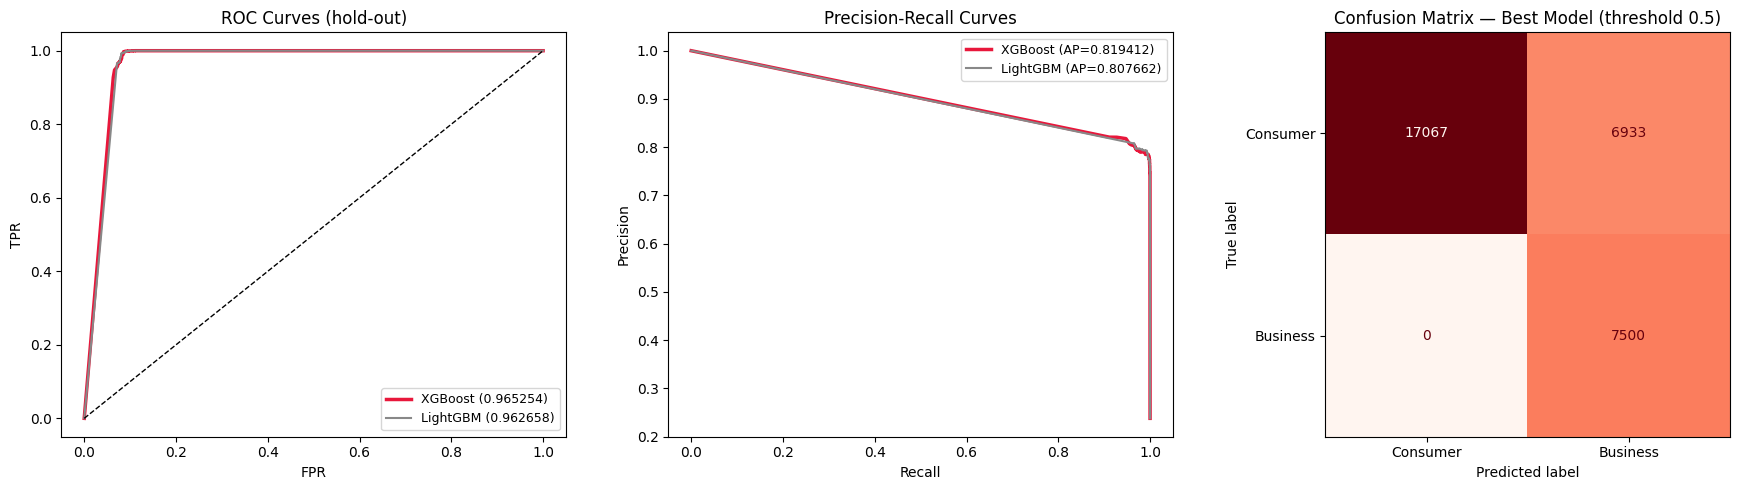

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_plot_cfg = [
    ('XGBoost',  xgb_prob_test,  '#E8173B', 2.5),
    ('LightGBM', lgbm_prob_test, '#888888', 1.5),
]

for name, probs, color, lw in model_plot_cfg:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_test, probs):.6f})', lw=lw, color=color)

    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.6f})', lw=lw, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curves (hold-out)')
axes[0].legend(fontsize=9)

axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves')
axes[1].legend(fontsize=9)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Consumer', 'Business']).plot(
    ax=axes[2], colorbar=False, cmap='Reds'
)
axes[2].set_title('Confusion Matrix — Best Model (threshold 0.5)')

plt.tight_layout()
plt.savefig('outputs/validation_metrics.png', dpi=100, bbox_inches='tight')
plt.show()


## 11b. SHAP — Why the Winner Model Decides

Now that the winning model is selected, we explain its predictions using SHAP.
Each point is one card. The x-axis shows how much a feature pushed the score
up (right) or down (left). Color shows the feature value: red = high, blue = low.

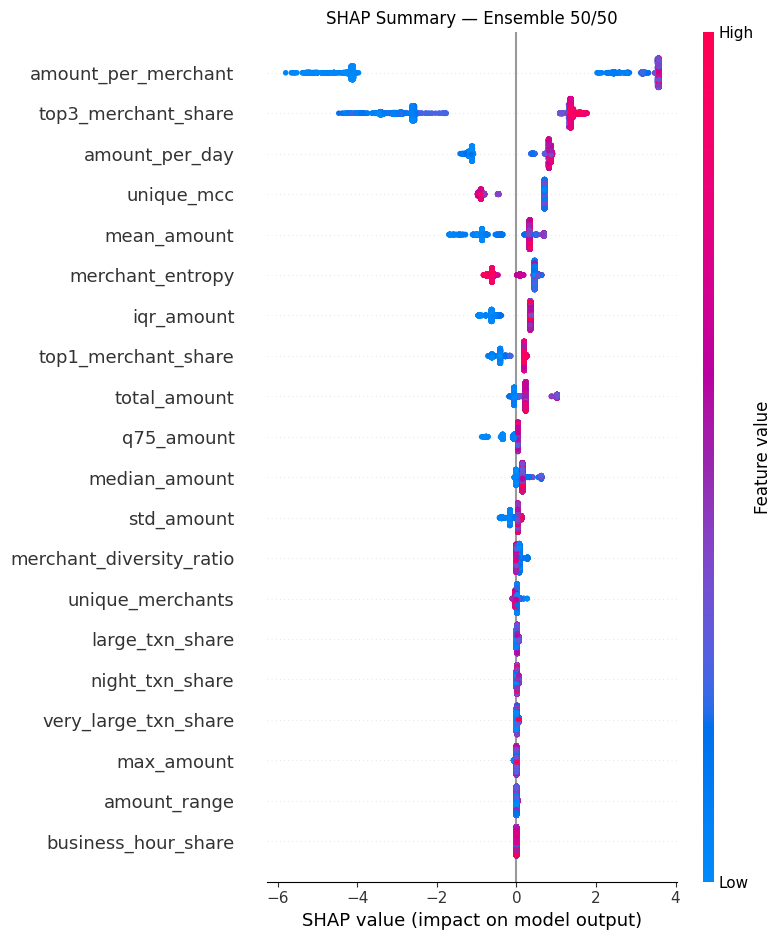

In [22]:
# Sample 2000 cards from each group for speed
rng = np.random.default_rng(42)
idx_biz  = rng.choice(len(feat_biz),  min(2000, len(feat_biz)),  replace=False)
idx_cons = rng.choice(len(feat_cons), min(2000, len(feat_cons)), replace=False)

X_shap = np.vstack([
    feat_biz.iloc[idx_biz][FEATURE_COLS].values,
    feat_cons.iloc[idx_cons][FEATURE_COLS].values
])

# winner_model is the best model from Section 11
sv = shap.TreeExplainer(winner_model).shap_values(X_shap)
sv = sv[1] if isinstance(sv, list) else sv

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS, show=False)
plt.title(f'SHAP Summary — {best_variant_name}')
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

## 12. Prediction on all consumer cards

- P95 (top 5%) — high model confidence: a personal manager is recommended
- P80–P95 (next 15%) — moderate confidence: a soft offer is suitable

In [23]:
def rank_normalize(scores):
    """Rank-based normalization: preserves order, spreads scores uniformly 0→1."""
    return rankdata(scores) / len(scores)

# 1. Compute raw scores
xgb_scores  = xgb_final.predict_proba(X_inf)[:, 1]
lgbm_scores = lgbm_final.predict_proba(X_inf)[:, 1]

# 2. Rank-normalize before ensembling
xgb_scores_norm  = rank_normalize(xgb_scores)
lgbm_scores_norm = rank_normalize(lgbm_scores)

_variants = {
    'XGBoost only':       xgb_scores_norm,
    'LightGBM only':      lgbm_scores_norm,
    'Ensemble 50/50':     rank_normalize(0.5 * xgb_scores_norm + 0.5 * lgbm_scores_norm),
    'Ensemble 70/30 XGB': rank_normalize(0.7 * xgb_scores_norm + 0.3 * lgbm_scores_norm),
}

# 3. Select strategy chosen in Section 11
final_scores = _variants[best_variant_name]

# 4. Build submission DataFrame
submission = (
    pd.DataFrame({'card_number': feat_cons['card_number'].values, 'score': final_scores})
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)

# 5. Save
OUTPUT_DIR  = 'outputs'
OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'submission_final.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)
submission[['card_number', 'score']].to_csv(OUTPUT_FILE, index=False)

print(f'Final Selected Strategy: {best_variant_name}')
print(f'Total Cards Scored:      {len(submission):,}')
print(f'Submission Saved To:     {OUTPUT_FILE}')
print(f'\nScore Distribution ({best_variant_name}):')
print(submission['score'].describe().round(4))
print(f'Unique scores: {submission["score"].nunique():,}')
print(f'\nTop 10 Cards:')
print(submission.head(10).to_string(index=False))

Final Selected Strategy: Ensemble 50/50
Total Cards Scored:      80,000
Submission Saved To:     outputs/submission_final.csv

Score Distribution (Ensemble 50/50):
count    80000.0000
mean         0.5000
std          0.2870
min          0.1020
25%          0.2392
50%          0.4984
75%          0.7500
max          0.9687
Name: score, dtype: float64
Unique scores: 15,963

Top 10 Cards:
     card_number  score
5100610005930965 0.9687
5228598250008990 0.9687
5531511765014850 0.9687
5438818065991685 0.9687
5438818059339990 0.9687
5176512063625595 0.9687
5201499613980598 0.9687
5438817993501236 0.9687
5438817991617745 0.9687
5438817973867102 0.9687


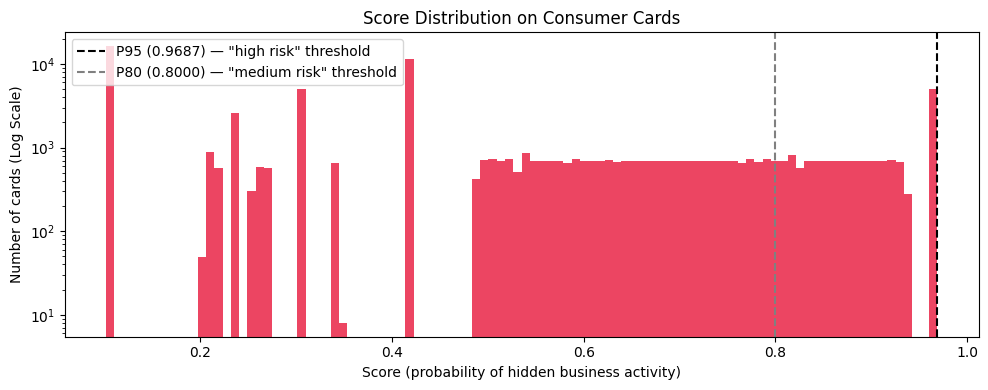

High risk (score ≥ P95=0.9687): 5,009 cards (6.3%)
Medium risk (P80–P95): 11,006 cards (13.8%)


In [24]:
plt.figure(figsize=(10, 4))

plt.hist(
    submission['score'],
    bins=100,
    color='#E8173B',
    alpha=0.8,
    edgecolor='none'
)
plt.yscale('log')  # Crucial fix for highly skewed anomaly scores

# Calculate quantiles safely
p95 = submission['score'].quantile(0.95)
p80 = submission['score'].quantile(0.80)

plt.axvline(
    p95,
    color='black',
    linestyle='--',
    label=f'P95 ({p95:.4f}) — "high risk" threshold'
)
plt.axvline(
    p80,
    color='gray',
    linestyle='--',
    label=f'P80 ({p80:.4f}) — "medium risk" threshold'
)

plt.xlabel('Score (probability of hidden business activity)')
plt.ylabel('Number of cards (Log Scale)')
plt.title('Score Distribution on Consumer Cards')
plt.legend()

# Ensure outputs directory exists before saving
os.makedirs('outputs', exist_ok=True)

plt.tight_layout()
plt.savefig(
    'outputs/score_distribution.png',
    dpi=100,
    bbox_inches='tight'
)
plt.show()

# Calculate segment counts
high_risk = (submission['score'] >= p95).sum()
mid_risk = (
    (submission['score'] >= p80) &
    (submission['score'] < p95)
).sum()

print(
    f'High risk (score ≥ P95={p95:.4f}): '
    f'{high_risk:,} cards ({high_risk / len(submission):.1%})'
)
print(
    f'Medium risk (P80–P95): '
    f'{mid_risk:,} cards ({mid_risk / len(submission):.1%})'
)

## 13. Top Map Analysis - Business Interpretation

In [25]:
# 1. Filter out the top 5% highest-scoring card numbers
top_cards = submission[
    submission['score'] >= p95
]['card_number'].tolist()

# 2. Extract feature records for these high-risk cards
top_feat = feat_cons[
    feat_cons['card_number'].isin(top_cards)
]

# 3. Specify behavioral metrics to analyze
compare_cols = [
    'txn_count',
    'total_amount',
    'unique_merchants',
    'unique_mcc',
    'top1_merchant_share',
    'merchant_diversity_ratio',
    'weekend_share',
    'business_hour_share',
    'amount_per_day',
    'large_txn_share',
    'txn_gap_std'
]

# 4. Generate the profile comparison table 
comparison = pd.DataFrame({
    'Top 5% (High Score)': top_feat[compare_cols].mean(),
    'All Consumer Cards':  feat_cons[compare_cols].mean(),
    'Business Cards (Reference)': feat_biz[compare_cols].mean()
}).round(3)

print('Profile Analysis: Comparison of Key Features (Mean Values)')

# Display the final comparison DataFrame
comparison

Profile Analysis: Comparison of Key Features (Mean Values)


,Top 5% (High Score),All Consumer Cards,Business Cards (Reference)
txn_count,1.091650e+02,122.906,1.199040e+02
total_amount,2.178072e+07,6642511.708,1.876916e+07
unique_merchants,1.255200e+01,36.750,1.708700e+01
unique_mcc,1.205100e+01,31.683,1.484900e+01
top1_merchant_share,5.250000e-01,0.161,3.680000e-01
merchant_diversity_ratio,1.230000e-01,0.324,1.570000e-01
weekend_share,2.510000e-01,0.345,1.290000e-01
business_hour_share,6.590000e-01,0.612,7.010000e-01
amount_per_day,2.950721e+05,76621.073,2.371492e+05
large_txn_share,1.620000e-01,0.025,1.110000e-01


## 14. Conclusions and Limitations

### Final model selection

The final scoring strategy is selected automatically based on hold-out AUC-ROC.

In this run, the best strategy was **Ensemble 50/50**, combining XGBoost and LightGBM with equal weights.

| Model / Strategy | Hold-Out AUC-ROC | Hold-Out PR-AUC |
|---|---:|---:|
| XGBoost only | 0.965254 | 0.819412 |
| LightGBM only | 0.962658 | 0.807662 |
| Ensemble 50/50 | **0.965299** | — |
| Ensemble 70/30 XGB | 0.965289 | — |

*PR-AUC reported for base models only; ensemble scores are derived from their weighted combination.*

The ensemble marginally outperforms both individual models on AUC-ROC. Both components contribute roughly equally (Spearman correlation between the two models: 0.95), while their combination reduces variance. SHAP interpretation in Section 11b uses `xgb_final` as the dominant component, since `TreeExplainer` requires a single model.

### Validation interpretation

The validation is proxy-based:
- known business cards are treated as positive examples;
- consumer cards are treated as unlabeled during PU-learning;
- hold-out consumer cards are used as proxy negatives only for evaluation.

The classification report reflects this setup: recall on the Business class is 1.00 at the default threshold, while Consumer precision is high (1.00) but recall is lower (0.71) — meaning the model errs toward flagging rather than missing. For a ranking task this is acceptable; the score itself, not a hard threshold, should drive business decisions.

The score should be interpreted as a **ranking signal**: higher score means the card behaves more similarly to known business cards. It is not definitive proof of commercial activity.

### Key indicators of hidden business behavior

High-scoring consumer cards are characterized by:
1. Higher total transaction volume.
2. Higher amount per active day.
3. Higher merchant concentration, especially `top1_merchant_share` and `top3_merchant_share`.
4. Lower merchant diversity compared with average consumer cards.
5. Higher share of large transactions.
6. More business-hour activity.
7. Transaction profiles closer to known business-card behavior.

### Business recommendations

1. **Score ≥ P95** — high-priority segment: personal manager outreach, direct business card offer, acquiring or SME products.
2. **Score P80–P95** — medium-priority: soft in-app offers and targeted business-product campaigns.
3. **Score P60–P80** — watchlist: low-cost monitoring and future retargeting.
4. Use campaign outcomes to recalibrate thresholds and retrain the model periodically.

### Limitations

- True labels for hidden business activity inside consumer cards are not available.
- PU-learning reduces negative-label noise, but reliable negatives are still an approximation.
- Hold-out metrics measure separation between known business cards and proxy consumer negatives, not real-world hidden-business detection accuracy.
- Synthetic data likely exaggerates class separability; live performance will differ.
- Final deployment would require calibration on real campaign outcomes, monitoring, and periodic retraining.

In [26]:
print('FINAL RESULTS')
print(f'Final selected strategy:       {best_variant_name}')
print(f'Best Hold-Out AUC:             {best_auc:.6f}')
print(
    f'Hold-Out AUC (XGBoost):        '
    f'{auc_xgb:.6f} '
)
print(
    f'Hold-Out AUC (LightGBM):       '
    f'{auc_lgbm:.6f}'
)
print(f'Features used:                 {len(FEATURE_COLS)}')
print(
    f'Cards scored:                  '
    f'{len(submission):,}'
)
print(f'Submission file:               {OUTPUT_FILE}')
print('Libraries: pandas, numpy, scikit-learn, xgboost, lightgbm, optuna, shap')
print()

FINAL RESULTS
Final selected strategy:       Ensemble 50/50
Best Hold-Out AUC:             0.965299
Hold-Out AUC (XGBoost):        0.965254 
Hold-Out AUC (LightGBM):       0.962658
Features used:                 31
Cards scored:                  80,000
Submission file:               outputs/submission_final.csv
Libraries: pandas, numpy, scikit-learn, xgboost, lightgbm, optuna, shap

